In [2]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint ,ReduceLROnPlateau



In [2]:
image_size=(48,48)
batch_size=50
train_ds=image_dataset_from_directory(
    r"D:\projects\facec detection\Face_detection\image class emotion\train",
    image_size=image_size,
    batch_size=batch_size,
    #color_mode="grayscale",
    shuffle=True,
    validation_split=.2,
    subset="training",
    seed=42
)
val_ds=image_dataset_from_directory(
    r"D:\projects\facec detection\Face_detection\image class emotion\train",
    image_size=image_size,
    batch_size=batch_size,
    #color_mode="grayscale",
    shuffle=False,
    validation_split=.2,
    subset="validation",
    seed=42
)
test_ds=image_dataset_from_directory(
    r"D:\projects\facec detection\Face_detection\image class emotion\test",
    image_size=image_size,
    batch_size=batch_size,
    #color_mode="grayscale",
    shuffle=False
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.


In [3]:
classes_name=train_ds.class_names
num_classes=len(train_ds.class_names)
print(num_classes)
print(classes_name)

7
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


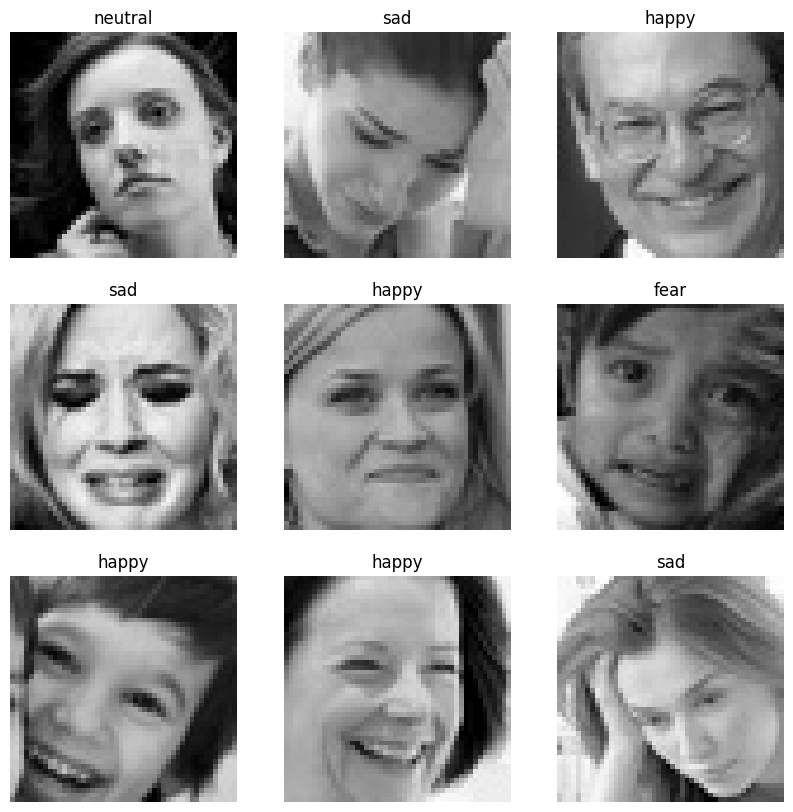

In [4]:
print(classes_name)
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(classes_name[labels[i]])
        plt.axis("off")
plt.show()


In [5]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
])
train_ds=train_ds.map(lambda x, y : (data_augmentation(x,training=True),y))


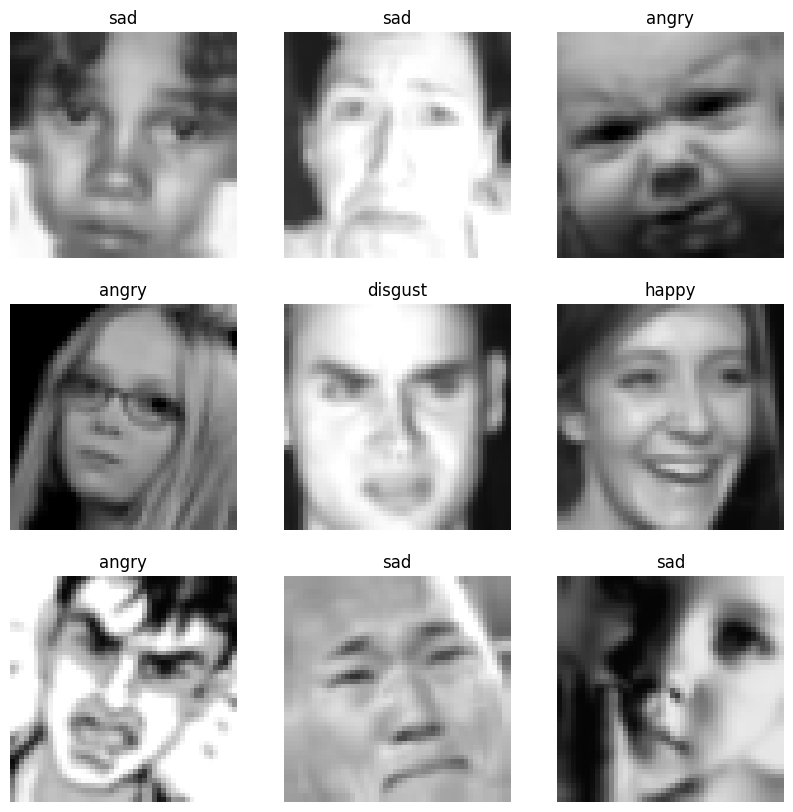

In [6]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images, training=True)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(classes_name[labels[i]])
        plt.axis("off")


In [7]:
normalization_layer=layers.Rescaling(1./255)
train_ds=train_ds.map(lambda x,y : (normalization_layer(x),y))
val_ds=val_ds.map(lambda x,y :(normalization_layer(x),y))
test_ds=test_ds.map(lambda x,y :(normalization_layer(x),y))

In [8]:
model=tf.keras.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(48,48,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(512, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.GlobalAvgPool2D(),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

c:\Users\G15\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 3, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,834,823 (7.00 MB)

 Trainable params: 1,834,823 (7.00 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
              )


In [10]:
history=model.fit(train_ds,validation_data=val_ds,epochs=60)

Epoch 1/60
460/460 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - accuracy: 0.2520 - loss: 1.8122 - val_accuracy: 0.0611 - val_loss: 1.9893
Epoch 2/60
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.3084 - loss: 1.7009 - val_accuracy: 0.4287 - val_loss: 1.5283
Epoch 3/60
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.4004 - loss: 1.5294 - val_accuracy: 0.4349 - val_loss: 1.4942
Epoch 4/60
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.4369 - loss: 1.4437 - val_accuracy: 0.5304 - val_loss: 1.3421
Epoch 5/60
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.4667 - loss: 1.3798 - val_accuracy: 0.5097 - val_loss: 1.3256
Epoch 6/60
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.4955 - loss: 1.3199 - val_accuracy: 0.5391 - val_loss: 1.2487
Epoch 7/60
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.5104 - loss: 1.2817 - val_accuracy: 0.5438 - val_loss: 1.2447
Epoch 8/60
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.5281 - loss: 1.2413 - 

In [11]:
model.evaluate(test_ds)

144/144 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.5719 - loss: 1.4487


[1.4487258195877075, 0.5718863010406494]

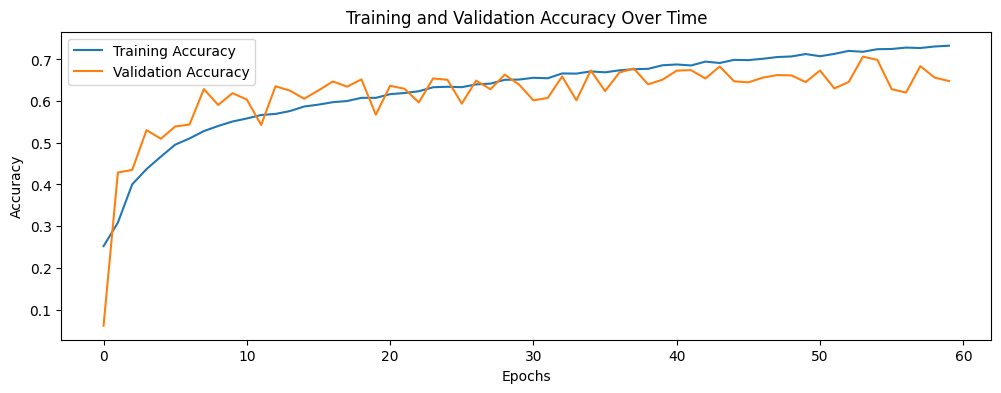

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy Over Time')
plt.legend()
plt.show()

In [13]:
model.save("best_emotion_model_scratch.keras")

# Enhance Model


In [14]:
from tensorflow.keras.models import load_model
model1=load_model("best_emotion_model_scratch.keras")

In [15]:
model1.fit(train_ds,validation_data=val_ds,epochs=80)

Epoch 1/80
460/460 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.7382 - loss: 0.7112 - val_accuracy: 0.6643 - val_loss: 0.9787
Epoch 2/80
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.7355 - loss: 0.7059 - val_accuracy: 0.7316 - val_loss: 0.7986
Epoch 3/80
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.7402 - loss: 0.7065 - val_accuracy: 0.6971 - val_loss: 0.8532
Epoch 4/80
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.7437 - loss: 0.6933 - val_accuracy: 0.6673 - val_loss: 0.9552
Epoch 5/80
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.7455 - loss: 0.6887 - val_accuracy: 0.6926 - val_loss: 0.9246
Epoch 6/80
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.7431 - loss: 0.6885 - val_accuracy: 0.6825 - val_loss: 0.9293
Epoch 7/80
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.7446 - loss: 0.6897 - val_accuracy: 0.6661 - val_loss: 0.9956
Epoch 8/80
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.7454 - loss: 0.6808 - 

In [17]:
model1.evaluate(test_ds)

144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5828 - loss: 1.9835


[1.9835436344146729, 0.5827528834342957]

In [18]:
model.save("best_emotion_model_scratch_enhanced.keras")

In [20]:
from tensorflow.keras.models import load_model
model2=load_model("best_emotion_model_scratch_enhanced.keras")

In [21]:
history2=model2.fit(train_ds,validation_data=val_ds,epochs=120)

Epoch 1/120
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.7313 - loss: 0.7198 - val_accuracy: 0.6711 - val_loss: 0.9506
Epoch 2/120
460/460 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.7352 - loss: 0.7067 - val_accuracy: 0.6788 - val_loss: 0.9487
Epoch 3/120
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.7426 - loss: 0.6995 - val_accuracy: 0.6983 - val_loss: 0.8687
Epoch 4/120
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.7396 - loss: 0.7016 - val_accuracy: 0.6657 - val_loss: 0.9882
Epoch 5/120
460/460 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.7424 - loss: 0.6943 - val_accuracy: 0.7002 - val_loss: 0.9202
Epoch 6/120
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.7423 - loss: 0.6973 - val_accuracy: 0.7030 - val_loss: 0.8738
Epoch 7/120
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.7396 - loss: 0.6948 - val_accuracy: 0.6715 - val_loss: 0.9698
Epoch 8/120
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.7468 - loss: 0

In [22]:
model2.evaluate(test_ds)

144/144 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.5624 - loss: 2.1843


[2.1843106746673584, 0.5624129176139832]

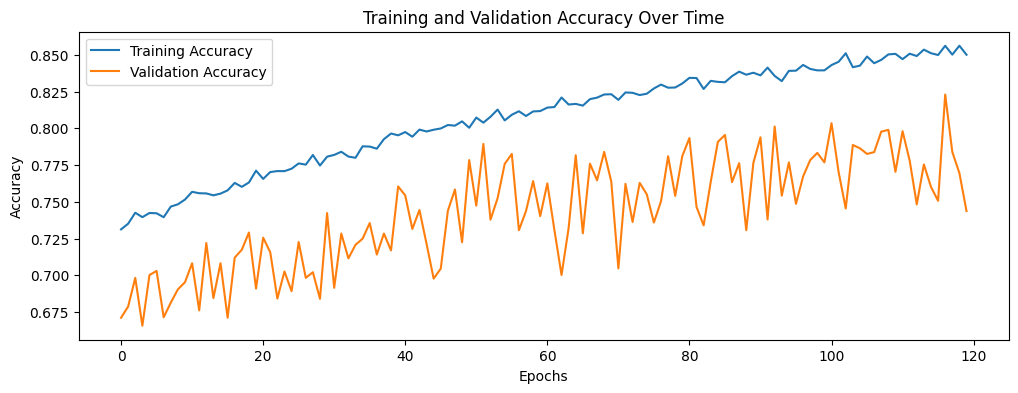

In [24]:
plt.figure(figsize=(12, 4))
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy Over Time')
plt.legend()
plt.show()

In [23]:
model2.save("best_emotion_model_scratch_enhanced_pro.keras")